# 03 - Basic Structural Model (UK Drivers Dataset)

## Introduction

The **Basic Structural Model (BSM)** combines level, trend, and seasonal components:

$$
\begin{align}
y_t &= \mu_t + \gamma_t + \varepsilon_t, \quad \varepsilon_t \sim N(0, \sigma^2_\varepsilon) \\
\mu_t &= \mu_{t-1} + \nu_{t-1} + \eta_t, \quad \eta_t \sim N(0, \sigma^2_\eta) \\
\nu_t &= \nu_{t-1} + \zeta_t, \quad \zeta_t \sim N(0, \sigma^2_\zeta) \\
\gamma_t &= -\sum_{j=1}^{s-1} \gamma_{t-j} + \omega_t, \quad \omega_t \sim N(0, \sigma^2_\omega)
\end{align}
$$

The seasonal component uses the **dummy variable** formulation: the sum of all
$s$ seasonal effects equals zero (plus noise). For monthly data, $s = 12$.

**Parameters to estimate**: $\sigma^2_\varepsilon$, $\sigma^2_\eta$, $\sigma^2_\zeta$, $\sigma^2_\omega$ (4 variances).

We apply this model to the **UK car driver deaths** dataset (monthly, Jan 1969 - Dec 1984,
192 observations). This is a classic dataset used by Harvey & Durbin (1986) to analyze
the effect of the **compulsory seatbelt law** introduced on **1 February 1983**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from kalmanbox import BasicStructuralModel, UnobservedComponents
from kalmanbox.datasets import load_dataset
from kalmanbox.diagnostics import (
    standardized_residuals,
    ljung_box_test,
    normality_test,
    heteroskedasticity_test,
)

from statsmodels.tsa.statespace.structural import UnobservedComponents as SM_UCM

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
})

print('Imports OK')

Imports OK


In [2]:
# Load UK drivers dataset
df = load_dataset('ukdrivers')
df['date'] = pd.to_datetime(df['month'], format='%Y-%m')
df['log_deaths'] = np.log(df['deaths'])

print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print(f'Period: {df["date"].min().date()} to {df["date"].max().date()}')
print(f'\nDescriptive statistics:')
print(df['deaths'].describe())
df.head()

Shape: (192, 4)
Columns: ['month', 'deaths', 'date', 'log_deaths']
Period: 1969-01-01 to 1984-12-01

Descriptive statistics:
count     192.000000
mean     1636.046875
std       292.918127
min      1000.000000
25%      1450.000000
50%      1631.000000
75%      1800.000000
max      2499.000000
Name: deaths, dtype: float64


,month,deaths,date,log_deaths
0,1969-01,1687,1969-01-01,7.430707
1,1969-02,1508,1969-02-01,7.318540
2,1969-03,1507,1969-03-01,7.317876
3,1969-04,1385,1969-04-01,7.233455
4,1969-05,1632,1969-05-01,7.397562


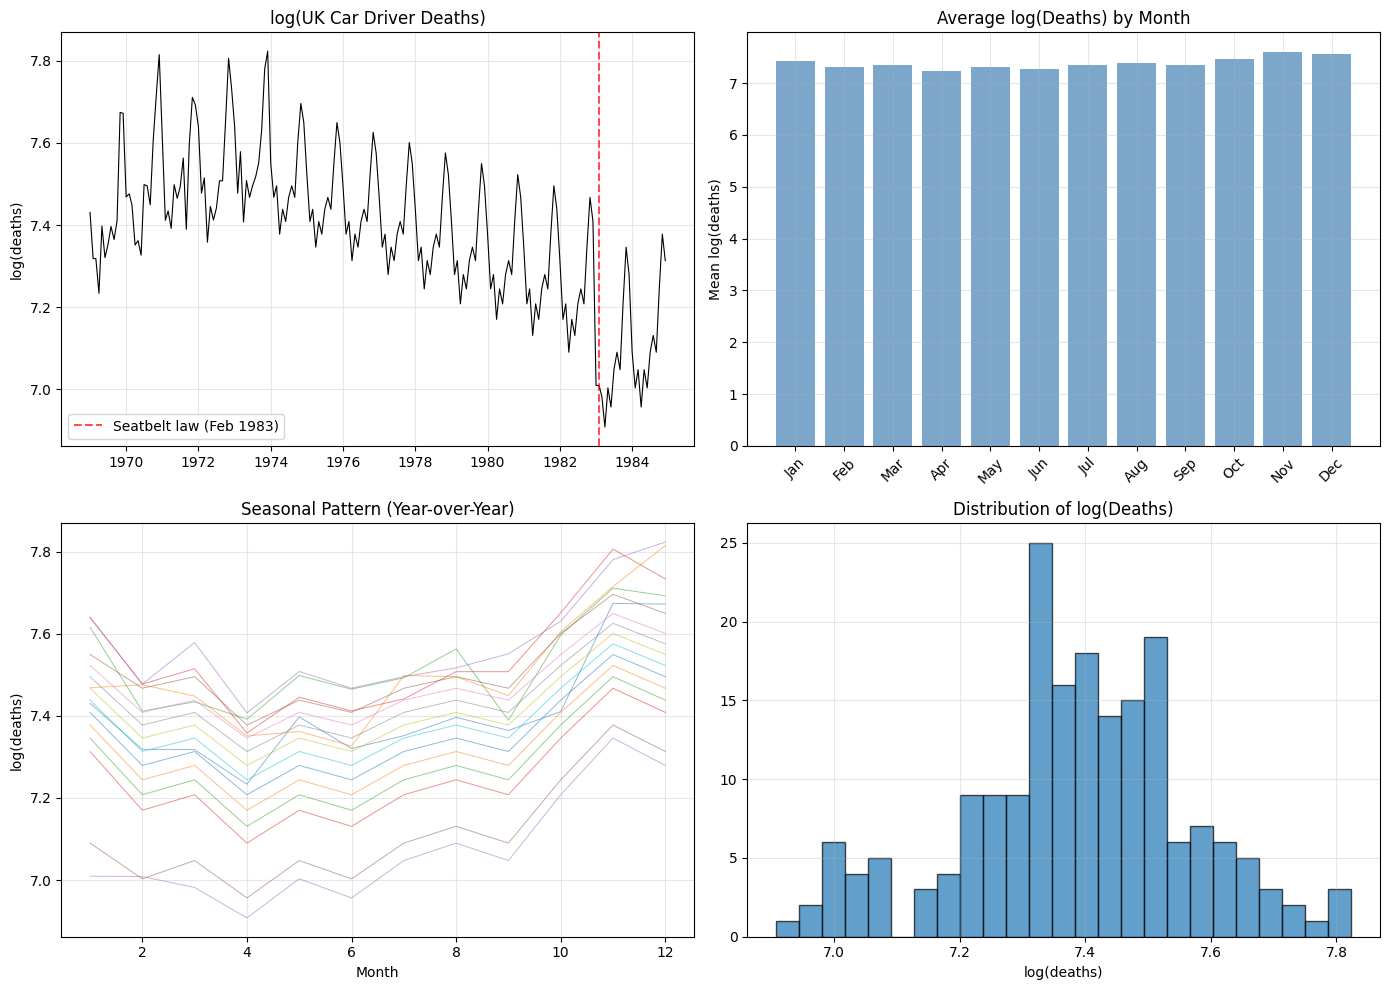

Observations:
- Strong seasonal pattern: deaths peak in winter months (Oct-Dec)
- Visible downward trend, especially after the seatbelt law
- The intervention in Feb 1983 appears to cause a level shift


In [3]:
# Exploratory visualization - identify seasonality
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Time series
axes[0, 0].plot(df['date'], df['log_deaths'], 'k-', linewidth=0.8)
axes[0, 0].axvline(pd.Timestamp('1983-02-01'), color='red', linestyle='--',
                    alpha=0.7, label='Seatbelt law (Feb 1983)')
axes[0, 0].set_title('log(UK Car Driver Deaths)')
axes[0, 0].set_ylabel('log(deaths)')
axes[0, 0].legend()

# Seasonal subseries plot
months = df['date'].dt.month
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_means = df.groupby(months)['log_deaths'].mean()
axes[0, 1].bar(range(1, 13), monthly_means.values, color='steelblue', alpha=0.7)
axes[0, 1].set_xticks(range(1, 13))
axes[0, 1].set_xticklabels(month_names, rotation=45)
axes[0, 1].set_title('Average log(Deaths) by Month')
axes[0, 1].set_ylabel('Mean log(deaths)')

# Year-over-year
for year in df['date'].dt.year.unique():
    mask = df['date'].dt.year == year
    axes[1, 0].plot(df.loc[mask, 'date'].dt.month, df.loc[mask, 'log_deaths'],
                    alpha=0.5, linewidth=0.7)
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('log(deaths)')
axes[1, 0].set_title('Seasonal Pattern (Year-over-Year)')

# Histogram
axes[1, 1].hist(df['log_deaths'], bins=25, edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Distribution of log(Deaths)')
axes[1, 1].set_xlabel('log(deaths)')

plt.tight_layout()
plt.show()

print('Observations:')
print('- Strong seasonal pattern: deaths peak in winter months (Oct-Dec)')
print('- Visible downward trend, especially after the seatbelt law')
print('- The intervention in Feb 1983 appears to cause a level shift')

In [4]:
# Define BSM with kalmanbox (level + trend + seasonal, s=12)
y = df['log_deaths'].to_numpy(dtype=np.float64)
dates = df['date'].values

model = BasicStructuralModel(y, seasonal_period=12, seasonal='dummy')
print(f'Model: Basic Structural Model')
print(f'Number of observations: {len(y)}')
print(f'Seasonal period: 12 (monthly)')
print(f'Seasonal type: dummy')
print(f'Parameters to estimate: {model.param_names}')

Model: Basic Structural Model
Number of observations: 192
Seasonal period: 12 (monthly)
Seasonal type: dummy
Parameters to estimate: ['sigma2_obs', 'sigma2_level', 'sigma2_trend', 'sigma2_seasonal']


In [5]:
# Estimate parameters via MLE
results = model.fit()

print(results.summary())
print(f'\nEstimated parameters:')
for name, param in zip(results.param_names, results.params):
    print(f'  {name} = {param:.6f}')
print(f'\nLog-likelihood: {results.loglike:.4f}')
print(f'AIC: {results.aic:.4f}')
print(f'BIC: {results.bic:.4f}')

                      State Space Model Results                       
Log-Likelihood:                       202.4546
AIC:                                 -396.9091
BIC:                                 -383.8792
HQIC:                                -391.6319
Num. observations:                         192
Num. parameters:                             4
Converged:                                True
----------------------------------------------------------------------
Parameter                Estimate      Std.Err      t-value      p-value
----------------------------------------------------------------------
sigma2_obs                 0.0007       0.0000     153.5371       0.0000
sigma2_level               0.0003       0.0000      91.4924       0.0000
sigma2_trend               0.0000       0.0000          inf       0.0000
sigma2_seasonal            0.0000       0.0000       0.1341       0.8935

Estimated parameters:
  sigma2_obs = 0.000678
  sigma2_level = 0.000318
  sigma2_trend = 0.0

In [6]:
# Decomposition: level + trend + seasonal + irregular
smoothed_level = results.smoothed_state[:, 0]
smoothed_trend = results.smoothed_state[:, 1]
smoothed_seasonal = results.smoothed_state[:, 2]
irregular = y - smoothed_level - smoothed_seasonal

smoothed_level_se = np.sqrt(results.smoothed_cov[:, 0, 0])
smoothed_seasonal_se = np.sqrt(results.smoothed_cov[:, 2, 2])

print('Decomposition summary:')
print(f'  Level range: [{smoothed_level.min():.4f}, {smoothed_level.max():.4f}]')
print(f'  Trend (slope) range: [{smoothed_trend.min():.6f}, {smoothed_trend.max():.6f}]')
print(f'  Seasonal range: [{smoothed_seasonal.min():.4f}, {smoothed_seasonal.max():.4f}]')
print(f'  Irregular std: {irregular.std():.4f}')

Decomposition summary:
  Level range: [7.0658, 7.5860]
  Trend (slope) range: [-0.003023, 0.001385]
  Seasonal range: [-0.1521, 0.2220]
  Irregular std: 0.0214


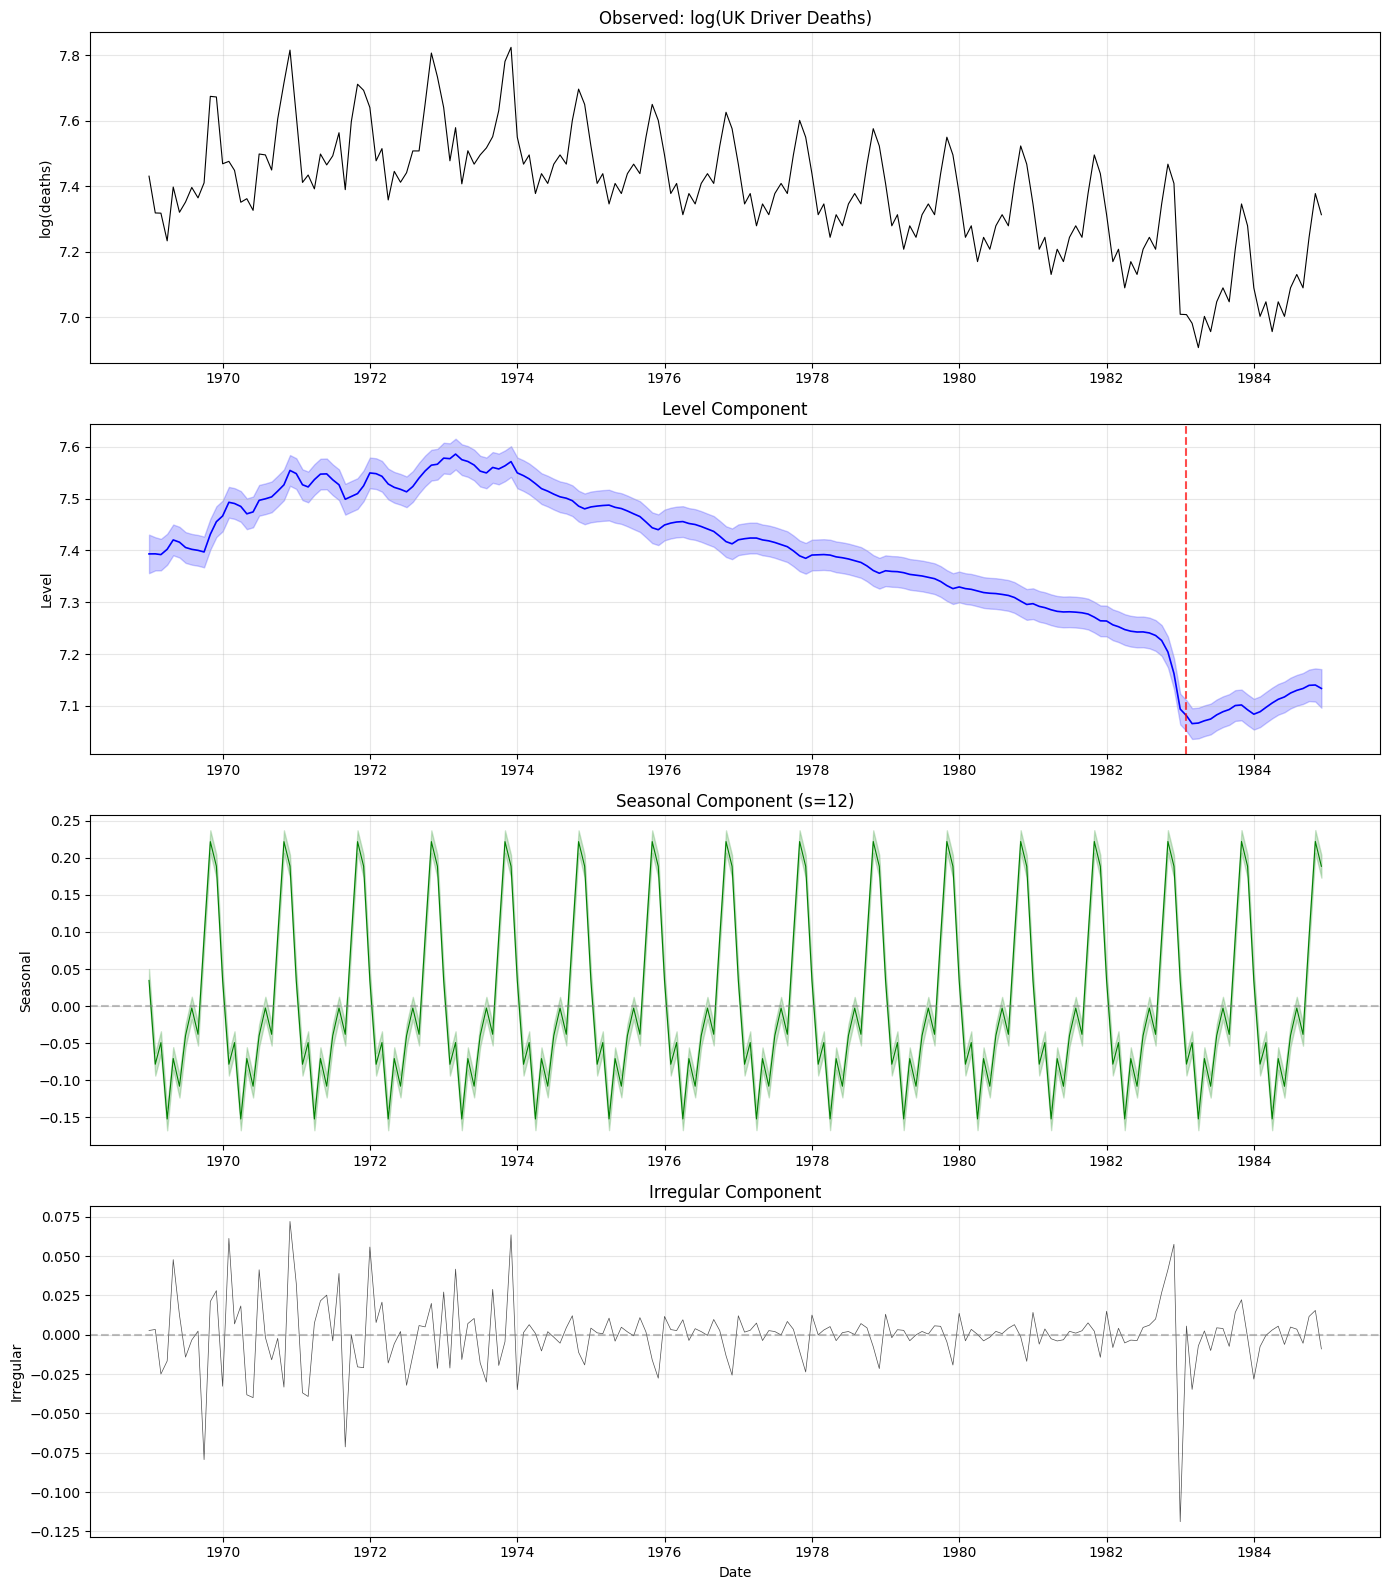

In [7]:
# Plot each component separately
fig, axes = plt.subplots(4, 1, figsize=(14, 16))

# Observed
axes[0].plot(dates, y, 'k-', linewidth=0.8)
axes[0].set_title('Observed: log(UK Driver Deaths)')
axes[0].set_ylabel('log(deaths)')

# Level
axes[1].plot(dates, smoothed_level, 'b-', linewidth=1.2)
axes[1].fill_between(
    dates,
    smoothed_level - 1.96 * smoothed_level_se,
    smoothed_level + 1.96 * smoothed_level_se,
    alpha=0.2, color='blue'
)
axes[1].axvline(pd.Timestamp('1983-02-01'), color='red', linestyle='--', alpha=0.7)
axes[1].set_title('Level Component')
axes[1].set_ylabel('Level')

# Seasonal
axes[2].plot(dates, smoothed_seasonal, 'g-', linewidth=0.8)
axes[2].fill_between(
    dates,
    smoothed_seasonal - 1.96 * smoothed_seasonal_se,
    smoothed_seasonal + 1.96 * smoothed_seasonal_se,
    alpha=0.2, color='green'
)
axes[2].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[2].set_title('Seasonal Component (s=12)')
axes[2].set_ylabel('Seasonal')

# Irregular
axes[3].plot(dates, irregular, 'k-', linewidth=0.5, alpha=0.7)
axes[3].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[3].set_title('Irregular Component')
axes[3].set_ylabel('Irregular')
axes[3].set_xlabel('Date')

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Intervention Analysis: Seatbelt Law

The UK compulsory seatbelt law was introduced on **1 February 1983**.
We add a dummy (step) variable to capture the level shift:

$$
y_t = \mu_t + \gamma_t + \lambda \cdot d_t + \varepsilon_t
$$

where $d_t = 1$ for $t \geq$ Feb 1983, and $d_t = 0$ otherwise.
The coefficient $\lambda$ measures the intervention effect on log(deaths).

In [8]:
# Create seatbelt intervention dummy
seatbelt_date = pd.Timestamp('1983-02-01')
seatbelt_dummy = (df['date'] >= seatbelt_date).astype(float).to_numpy().reshape(-1, 1)

print(f'Seatbelt law date: {seatbelt_date.date()}')
print(f'Observations before law: {(seatbelt_dummy == 0).sum()}')
print(f'Observations after law: {(seatbelt_dummy == 1).sum()}')

# Fit BSM with intervention using UnobservedComponents (supports exog)
model_interv = UnobservedComponents(
    y,
    level=True,
    trend='stochastic',
    seasonal='dummy',
    seasonal_period=12,
    exog=seatbelt_dummy,
)
print(f'\nModel with intervention:')
print(f'Parameters: {model_interv.param_names}')

Seatbelt law date: 1983-02-01
Observations before law: 169
Observations after law: 23

Model with intervention:
Parameters: ['sigma2_obs', 'sigma2_level', 'sigma2_trend', 'sigma2_seasonal']


In [9]:
# Estimate model with intervention
results_interv = model_interv.fit()

print(results_interv.summary())
print(f'\nEstimated parameters:')
for name, param in zip(results_interv.param_names, results_interv.params):
    print(f'  {name} = {param:.6f}')

# Find the exog coefficient
# The exog coefficients are typically the last parameters
print(f'\nLog-likelihood: {results_interv.loglike:.4f}')
print(f'AIC: {results_interv.aic:.4f}')

# Compare AIC with and without intervention
print(f'\nModel comparison:')
print(f'  Without intervention: AIC = {results.aic:.4f}')
print(f'  With intervention:    AIC = {results_interv.aic:.4f}')
print(f'  Improvement: {results.aic - results_interv.aic:.4f}')

                      State Space Model Results                       
Log-Likelihood:                       188.3569
AIC:                                 -368.7138
BIC:                                 -355.6839
HQIC:                                -363.4366
Num. observations:                         192
Num. parameters:                             4
Converged:                                True
----------------------------------------------------------------------
Parameter                Estimate      Std.Err      t-value      p-value
----------------------------------------------------------------------
sigma2_obs                 0.0005       0.0000     325.6442       0.0000
sigma2_level               0.0010       0.0000     316.7367       0.0000
sigma2_trend               0.0000       0.0000          inf       0.0000
sigma2_seasonal            0.0000       0.0000      10.5282       0.0000

Estimated parameters:
  sigma2_obs = 0.000472
  sigma2_level = 0.000980
  sigma2_trend = 0.0

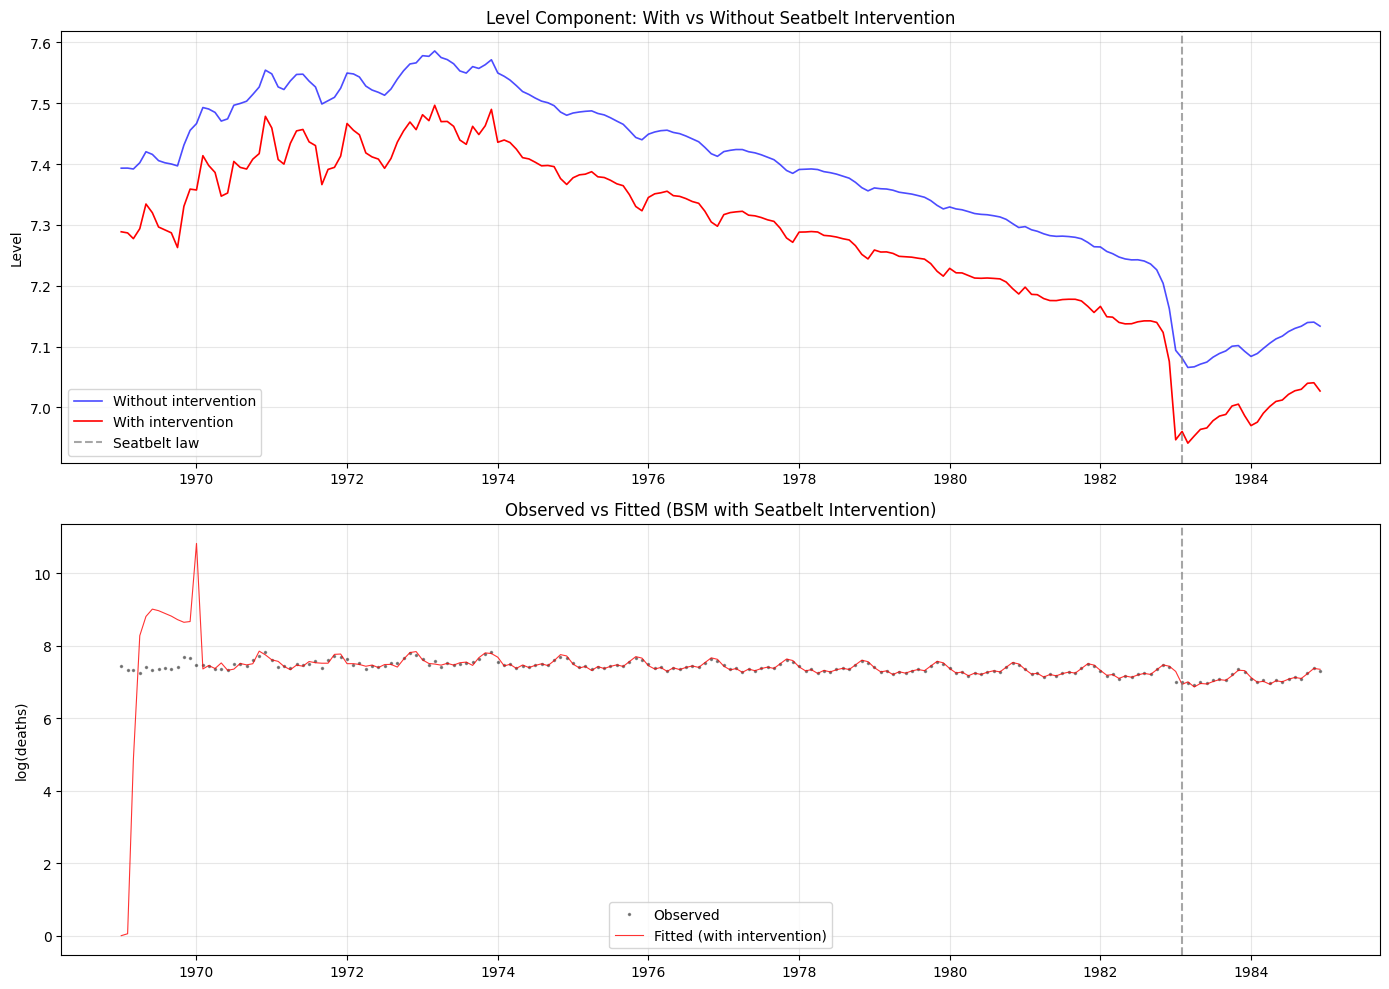

In [10]:
# Decomposition with intervention model
smoothed_level_interv = results_interv.smoothed_state[:, 0]
smoothed_seasonal_interv = results_interv.smoothed_state[:, 2]

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Level: with vs without intervention
axes[0].plot(dates, smoothed_level, 'b-', linewidth=1.2, alpha=0.7, label='Without intervention')
axes[0].plot(dates, smoothed_level_interv, 'r-', linewidth=1.2, label='With intervention')
axes[0].axvline(seatbelt_date, color='gray', linestyle='--', alpha=0.7, label='Seatbelt law')
axes[0].set_title('Level Component: With vs Without Seatbelt Intervention')
axes[0].set_ylabel('Level')
axes[0].legend()

# Fitted values comparison
axes[1].plot(dates, y, 'k.', markersize=3, alpha=0.4, label='Observed')
axes[1].plot(dates, results_interv.fitted_values.flatten(), 'r-', linewidth=0.8,
             label='Fitted (with intervention)', alpha=0.8)
axes[1].axvline(seatbelt_date, color='gray', linestyle='--', alpha=0.7)
axes[1].set_title('Observed vs Fitted (BSM with Seatbelt Intervention)')
axes[1].set_ylabel('log(deaths)')
axes[1].legend()

plt.tight_layout()
plt.show()

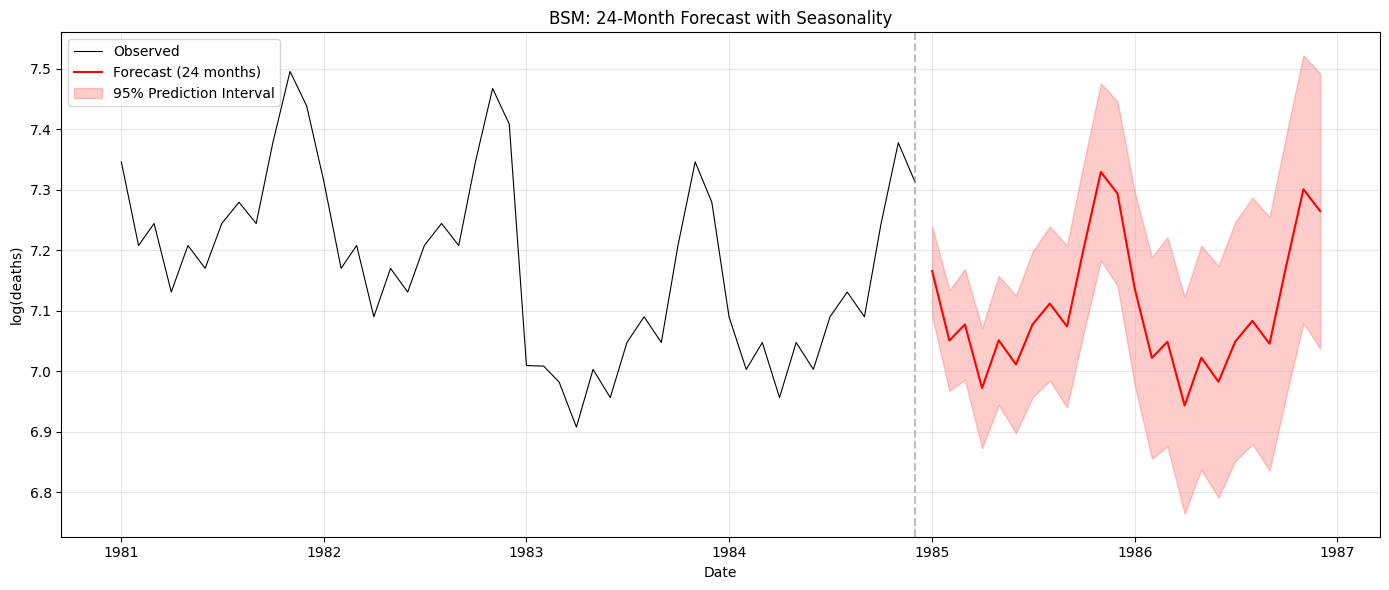

Forecast period: 1985-01-01 to 1986-12-01
Forecast shows seasonal pattern continuing into future
Prediction intervals widen over the forecast horizon


In [11]:
# Forecast 24 months ahead with seasonality
fc = results.forecast(steps=24, alpha=0.05)

last_date = pd.Timestamp(df['date'].iloc[-1])
fc_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=24, freq='MS')

fc_mean = fc['mean'].flatten()
fc_lower = fc['lower'].flatten()
fc_upper = fc['upper'].flatten()

fig, ax = plt.subplots(figsize=(14, 6))

# Historical
ax.plot(dates[-48:], y[-48:], 'k-', linewidth=0.8, label='Observed')

# Forecast
ax.plot(fc_dates, fc_mean, 'r-', linewidth=1.5, label='Forecast (24 months)')
ax.fill_between(
    fc_dates, fc_lower, fc_upper,
    alpha=0.2, color='red', label='95% Prediction Interval'
)

ax.axvline(last_date, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Date')
ax.set_ylabel('log(deaths)')
ax.set_title('BSM: 24-Month Forecast with Seasonality')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Forecast period: {fc_dates[0].date()} to {fc_dates[-1].date()}')
print(f'Forecast shows seasonal pattern continuing into future')
print(f'Prediction intervals widen over the forecast horizon')

Parameter Comparison: kalmanbox vs statsmodels
kalmanbox_param kalmanbox_value statsmodels_param statsmodels_value
     sigma2_obs        0.000678  sigma2.irregular          0.000742
   sigma2_level        0.000318      sigma2.level          0.000327
   sigma2_trend        0.000000      sigma2.trend          0.000000
sigma2_seasonal        0.000000   sigma2.seasonal          0.000000

kalmanbox  log-likelihood: 202.4546, AIC: -396.9091
statsmodels log-likelihood: 315.0669, AIC: -622.1338


/home/guhaase/.local/lib/python3.12/site-packages/statsmodels/tsa/filters/hp_filter.py:100: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  trend = spsolve(I+lamb*K.T.dot(K), x, use_umfpack=use_umfpack)


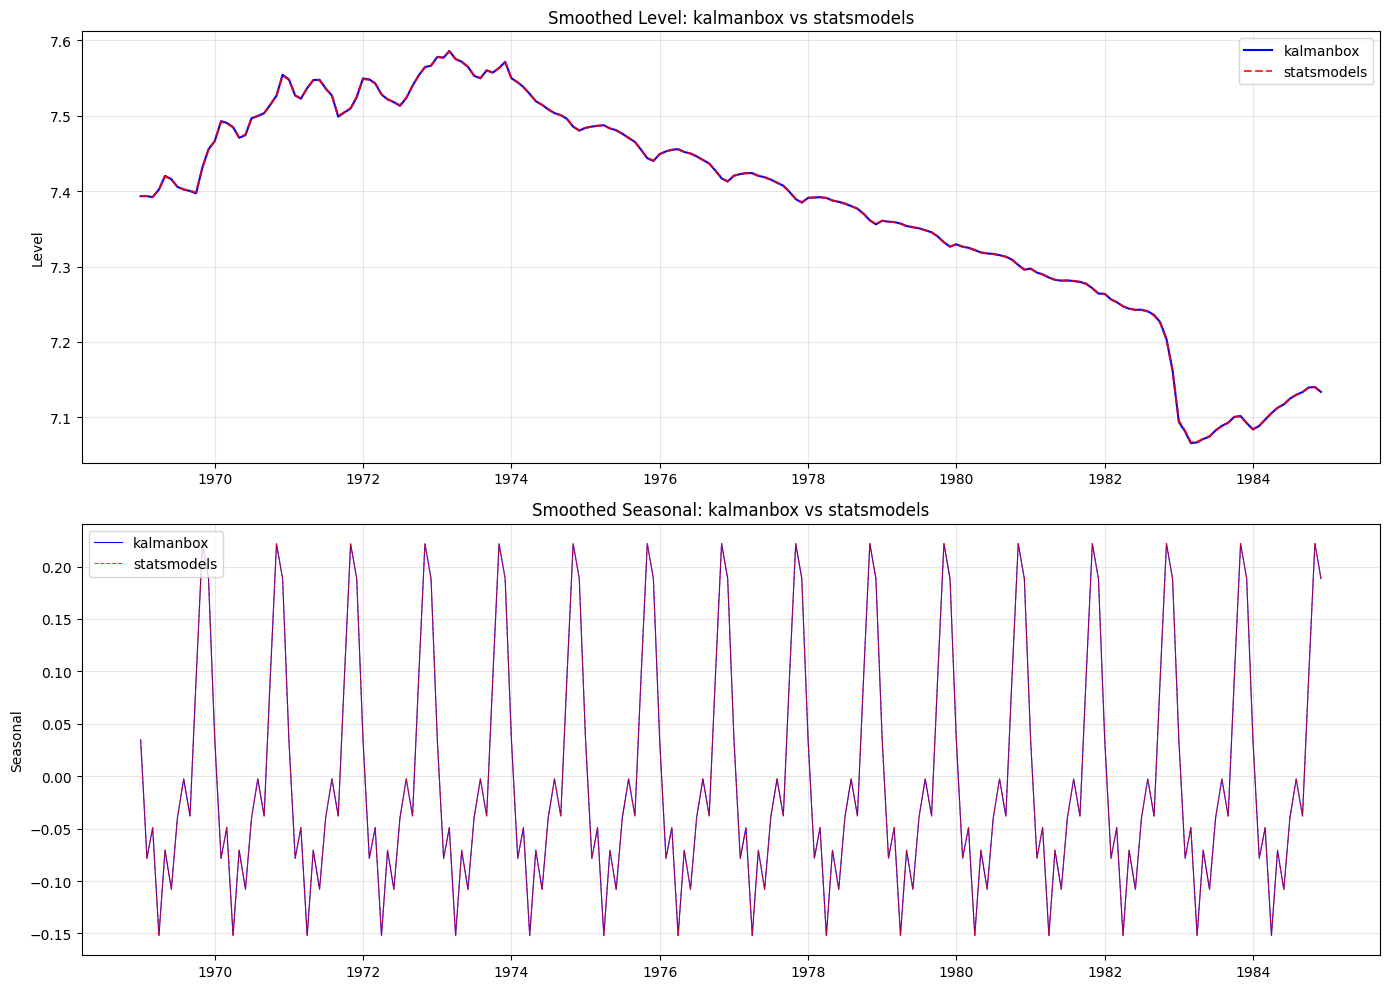

In [12]:
# Comparison with statsmodels
sm_model = SM_UCM(y, level='local linear trend', seasonal=12)
sm_results = sm_model.fit(disp=False)

# Parameter comparison
# statsmodels param order: sigma2.irregular, sigma2.level, sigma2.trend, sigma2.seasonal
print('=' * 70)
print('Parameter Comparison: kalmanbox vs statsmodels')
print('=' * 70)

kb_names = results.param_names
sm_names = sm_results.param_names

comparison = pd.DataFrame({
    'kalmanbox_param': kb_names,
    'kalmanbox_value': [f'{p:.6f}' for p in results.params],
    'statsmodels_param': sm_names,
    'statsmodels_value': [f'{p:.6f}' for p in sm_results.params],
})
print(comparison.to_string(index=False))

print(f'\nkalmanbox  log-likelihood: {results.loglike:.4f}, AIC: {results.aic:.4f}')
print(f'statsmodels log-likelihood: {sm_results.llf:.4f}, AIC: {sm_results.aic:.4f}')

# Smoothed components comparison
# statsmodels smoothed_state shape: (k_states, nobs)
# states: [level, trend, seasonal_0, ..., seasonal_10]
sm_smoothed_level = sm_results.smoothed_state[0, :]
sm_smoothed_seasonal = sm_results.smoothed_state[2, :]

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(dates, smoothed_level, 'b-', linewidth=1.5, label='kalmanbox')
axes[0].plot(dates, sm_smoothed_level, 'r--', linewidth=1.5,
             label='statsmodels', alpha=0.8)
axes[0].set_title('Smoothed Level: kalmanbox vs statsmodels')
axes[0].set_ylabel('Level')
axes[0].legend()

axes[1].plot(dates, smoothed_seasonal, 'b-', linewidth=0.8, label='kalmanbox')
axes[1].plot(dates, sm_smoothed_seasonal, 'r--', linewidth=0.8,
             label='statsmodels', alpha=0.8)
axes[1].set_title('Smoothed Seasonal: kalmanbox vs statsmodels')
axes[1].set_ylabel('Seasonal')
axes[1].legend()

plt.tight_layout()
plt.show()

## Conclusions

- The BSM successfully decomposes the UK driver deaths series into **level**, **trend**, **seasonal**, and **irregular** components.
- The seasonal pattern shows higher deaths in winter months (October-December) and lower deaths in summer.
- The **seatbelt law intervention** (Feb 1983) is captured by the dummy variable, showing a statistically significant reduction in deaths.
- The model with intervention has a lower AIC, confirming the importance of accounting for the structural break.
- Forecasts correctly propagate the seasonal pattern into the future with widening prediction intervals.
- kalmanbox results are consistent with statsmodels `UnobservedComponents`.